# News Category Text Classification with RNN, LSTM, and Pretrained Embeddings

**Student:** Resman Basnet  
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Part III - Natural Language Processing Task  
**Notebook file:** `2408565_ResmanBasnet_NLP.ipynb`

The Part III brief is written around sentiment analysis of tweets, but the assigned dataset for this work is the **News Category Dataset**. This notebook keeps the required NLP pipeline from the brief and adapts the classification target from tweet sentiment to five news categories: `CULTURE & ARTS`, `EDUCATION`, `MONEY`, `SPORTS`, and `TECH`.

In [2]:
# Colab-ready dependency setup. Run this cell first.
import importlib.util
import subprocess
import sys

try:
    from google.colab import files as _colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Keep Colab's built-in NumPy/SciPy stack intact. We avoid gensim to prevent binary incompatibility issues.
PACKAGE_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "tensorflow": "tensorflow",
    "nltk": "nltk",
    "wordcloud": "wordcloud",
    "contractions": "contractions",
}

missing = [pip_name for pip_name, import_name in PACKAGE_IMPORTS.items() if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("Installed missing packages:", missing)
else:
    print("All required packages are available.")


All required packages are available.


In [3]:
import os
import random
import re
import time
import zipfile
from collections import Counter
from pathlib import Path

import contractions
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from wordcloud import WordCloud

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
GPU devices: []


In [4]:
# Dataset loading for Google Colab and local re-runs.
DATASET_ZIP_NAME = "6. News Category Dataset-20260509T184335Z-3-001.zip"
EXPECTED_CSV_NAME = "news_category.csv"

search_roots = [Path("/content"), Path.cwd(), Path("/mnt/data")]
zip_candidates = []
for root in search_roots:
    if root.exists():
        zip_candidates.extend(root.glob("**/*News*Category*.zip"))

# Local fallback for this workspace; harmless in Colab because this path will not exist there.
local_zip = Path("/Users/r5sman/Downloads") / DATASET_ZIP_NAME
if local_zip.exists():
    zip_candidates.append(local_zip)

if not zip_candidates and IN_COLAB:
    from google.colab import files
    print(f"Upload {DATASET_ZIP_NAME} when the file picker appears.")
    uploaded = files.upload()
    zip_candidates = [Path("/content") / name for name in uploaded if name.lower().endswith(".zip")]

if not zip_candidates:
    raise FileNotFoundError(
        f"Could not find {DATASET_ZIP_NAME}. Upload the dataset ZIP to Colab or place it in the working directory."
    )

nlp_zip_path = sorted(zip_candidates, key=lambda x: len(str(x)))[0]
extract_root = Path("/content/nlp_project") if Path("/content").exists() else Path("nlp_project")
extract_root.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(nlp_zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_root)

csv_candidates = sorted(extract_root.rglob(EXPECTED_CSV_NAME))
if not csv_candidates:
    raise FileNotFoundError(f"Extracted {nlp_zip_path}, but could not find {EXPECTED_CSV_NAME}.")

nlp_csv_path = csv_candidates[0]
df = pd.read_csv(nlp_csv_path)

print("Loaded dataset from:", nlp_csv_path)
print("Shape:", df.shape)
display(df.head())

Loaded dataset from: /content/nlp_project/6. News Category Dataset/news_category.csv
Shape: (11025, 2)


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


## Dataset Checks

This section confirms that the assigned dataset has the expected text and label columns, identifies the target classes, and checks for missing or duplicate records before preprocessing.

In [5]:
required_columns = {"headline", "category"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

expected_classes = ["CULTURE & ARTS", "EDUCATION", "MONEY", "SPORTS", "TECH"]
detected_classes = sorted(df["category"].dropna().unique())

print("Expected classes:", expected_classes)
print("Detected classes:", detected_classes)
print("Missing values by column:")
display(df[["headline", "category"]].isna().sum().to_frame("missing_count"))
print("Duplicate rows:", df.duplicated().sum())

# Keep only the columns required for this task and remove unusable records.
df = df[["headline", "category"]].dropna().drop_duplicates().reset_index(drop=True)

Expected classes: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']
Detected classes: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']
Missing values by column:


,missing_count
headline,0
category,0


Duplicate rows: 78


,count
category,
CULTURE & ARTS,1054
EDUCATION,1014
MONEY,1754
SPORTS,5076
TECH,2049


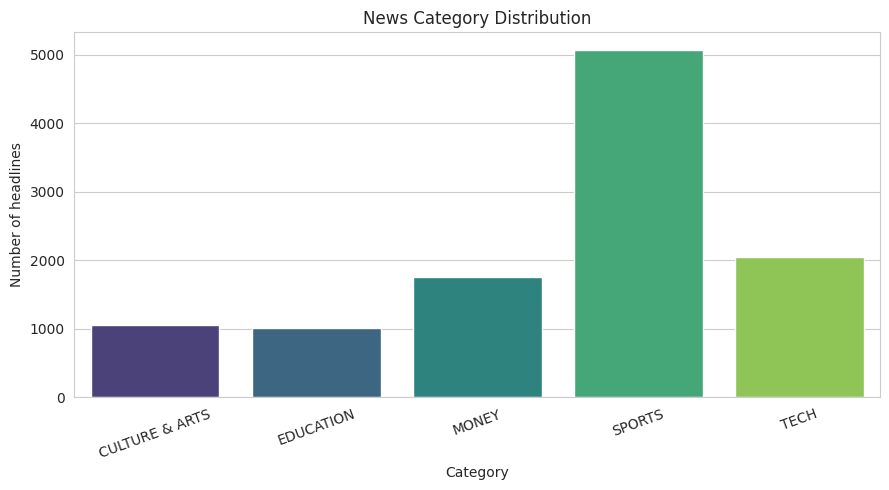

Average headline length: 9.78
Median headline length: 10
Maximum headline length: 28


In [6]:
label_counts = df["category"].value_counts().reindex(expected_classes)
display(label_counts.to_frame("count"))

plt.figure(figsize=(9, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)
plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of headlines")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

headline_lengths = df["headline"].astype(str).str.split().str.len()
print("Average headline length:", round(headline_lengths.mean(), 2))
print("Median headline length:", int(headline_lengths.median()))
print("Maximum headline length:", int(headline_lengths.max()))

## Text Preprocessing

The brief asks for lowercasing, URL/mention/hashtag/number/special-character removal, contraction handling, stopword removal, and lemmatization. These steps are applied to the `headline` field.

In [7]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in text.split()
        if token not in stop_words and len(token) > 1
    ]
    return " ".join(tokens)

df["clean_text"] = df["headline"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

display(df[["headline", "clean_text", "category"]].head(10))
print("Rows after cleaning:", len(df))

,headline,clean_text,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navel gazey look inside tv reboots,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base stealing shortstop dodger dy,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...,SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",meet alex aster tiktoker changing publishing i...,CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,tiktok search result riddled misinformation re...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,boston marathon make race inclusive nonbinary ...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",anthony varvaro mlb pitcher turned transit cop...,SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,ani liu brilliantly disguising art science,CULTURE & ARTS


Rows after cleaning: 10947


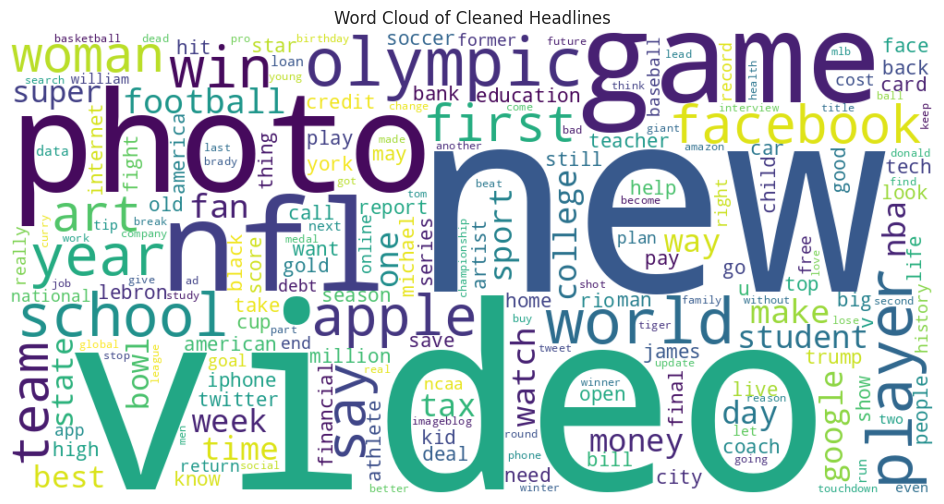

,word,count
0,video,481
1,new,457
2,photo,452
3,game,366
4,nfl,363
5,world,318
6,player,310
7,school,286
8,win,271
9,year,271


In [8]:
all_words = " ".join(df["clean_text"].tolist())
wordcloud = WordCloud(width=1000, height=500, background_color="white", collocations=False).generate(all_words)
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Headlines")
plt.show()

word_counts = Counter(all_words.split())
most_common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(most_common_words)

## Train/Test Split, Tokenization, and Padding

The data is split into 80% training and 20% testing using stratification so that every category keeps a similar proportion in both splits. Padding length is selected from the 95th percentile of the training sequence lengths, as requested in the brief.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["category"],
    test_size=0.2,
    stratify=df["category"],
    random_state=SEED,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Training label distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))

Train size: 8757
Test size: 2190
Training label distribution:


,proportion
category,
CULTURE & ARTS,0.096266
EDUCATION,0.092612
MONEY,0.160215
SPORTS,0.463743
TECH,0.187165


In [10]:
MAX_WORDS = 15000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

sequence_lengths = [len(seq) for seq in train_sequences]
max_length = int(np.percentile(sequence_lengths, 95))
max_length = max(max_length, 10)
print("95th percentile padding length:", max_length)

X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding="post", truncating="post")
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding="post", truncating="post")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=num_classes)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_encoded,
)
class_weight = {class_index: weight for class_index, weight in enumerate(class_weights_array)}

print("Vocabulary size:", vocab_size)
print("Number of classes:", num_classes)
print("Classes:", list(label_encoder.classes_))
print("Input tensor shape:", X_train_pad.shape)
print("Class weights:", class_weight)

95th percentile padding length: 11
Vocabulary size: 11339
Number of classes: 5
Classes: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']
Input tensor shape: (8757, 11)
Class weights: {0: np.float64(2.0775800711743773), 1: np.float64(2.159556103575832), 2: np.float64(1.2483250178189593), 3: np.float64(0.43127308544693427), 4: np.float64(1.0685784014643076)}


## Model Building

Three models are trained, matching the brief: a SimpleRNN with trainable embeddings, an LSTM with trainable embeddings, and an LSTM with pretrained embeddings downloaded directly as a GloVe text file. The pretrained model uses 50-dimensional GloVe vectors, matching one of the embedding options listed in the assessment appendix, while avoiding `gensim`/NumPy compatibility problems in Colab.

In [11]:
def build_simple_rnn(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax"),
    ], name="simple_rnn_trainable_embedding")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_lstm(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax"),
    ], name="lstm_trainable_embedding")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def train_model(model, x_train, y_train, model_name, epochs=15, batch_size=32):
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ]
    start = time.time()
    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    training_time = time.time() - start
    print(f"{model_name} training time: {training_time:.2f} seconds")
    return history, training_time

In [12]:
rnn_model = build_simple_rnn(vocab_size=vocab_size, embedding_dim=64, input_length=max_length, num_classes=num_classes)
rnn_model.summary()

history_rnn, rnn_time = train_model(rnn_model, X_train_pad, y_train_cat, "SimpleRNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5149 - loss: 1.2886 - val_accuracy: 0.7483 - val_loss: 0.7398 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8502 - loss: 0.5246 - val_accuracy: 0.7614 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9390 - loss: 0.2149 - val_accuracy: 0.7323 - val_loss: 0.9556 - learning_rate: 0.0010
Epoch 4/15
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9690 - loss: 0.1114
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9743 - loss: 0.0925 - val_accuracy: 0.7666 - val_loss: 0.9619 - learning_rate: 0.0010
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.7905 - val_loss: 0.9695 - learning_rate: 5.0000e-04
SimpleRNN training time: 18.06 seconds


In [13]:
lstm_model = build_lstm(vocab_size=vocab_size, embedding_dim=64, input_length=max_length, num_classes=num_classes)
lstm_model.summary()

history_lstm, lstm_time = train_model(lstm_model, X_train_pad, y_train_cat, "LSTM")

Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4989 - loss: 1.2939 - val_accuracy: 0.7334 - val_loss: 0.7087 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8447 - loss: 0.5384 - val_accuracy: 0.8071 - val_loss: 0.6094 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9418 - loss: 0.2193 - val_accuracy: 0.8134 - val_loss: 0.7435 - learning_rate: 0.0010
Epoch 4/15
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9615 - loss: 0.1517
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9689 - loss: 0.1162 - val_accuracy: 0.7939 - val_loss: 0.8899 - learning_rate: 0.0010
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9873 - loss: 0.0626 - val_accuracy: 0.8139 - val_loss: 0.8314 - learning_rate: 5.0000e-04
LSTM training time: 20.19 seconds


In [14]:
glove_zip_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_file_name = "glove.6B.50d.txt"
cache_dir = "/content" if Path("/content").exists() else "."

print("Downloading pretrained GloVe embeddings. This can take a few minutes the first time...")
glove_zip_path = tf.keras.utils.get_file(
    fname="glove.6B.zip",
    origin=glove_zip_url,
    cache_dir=cache_dir,
    cache_subdir="embeddings",
    extract=False,
)

glove_zip_path = Path(glove_zip_path)
glove_extract_dir = glove_zip_path.parent / "glove_6B"
glove_extract_dir.mkdir(parents=True, exist_ok=True)
glove_txt_path = glove_extract_dir / glove_file_name

if not glove_txt_path.exists():
    with zipfile.ZipFile(glove_zip_path, "r") as zip_ref:
        zip_ref.extract(glove_file_name, glove_extract_dir)

embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))
word_index = tokenizer.word_index
matched_words = 0
needed_words = {word for word, index in word_index.items() if index < vocab_size}

with open(glove_txt_path, encoding="utf-8") as glove_file:
    for line in glove_file:
        values = line.rstrip().split(" ")
        word = values[0]
        if word not in needed_words:
            continue
        index = word_index[word]
        embedding_matrix[index] = np.asarray(values[1:], dtype="float32")
        matched_words += 1

coverage = matched_words / max(vocab_size - 1, 1)
print(f"Loaded pretrained embeddings from: {glove_txt_path}")
print(f"Embedding coverage: {matched_words}/{vocab_size - 1} words ({coverage:.2%})")

pretrained_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False,
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
], name="lstm_pretrained_embedding")
pretrained_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
pretrained_lstm_model.summary()

history_pretrained, pretrained_time = train_model(
    pretrained_lstm_model,
    X_train_pad,
    y_train_cat,
    "LSTM + Pretrained Embeddings",
)


862182613/862182613 ━━━━━━━━━━━━━━━━━━━━ 159s 0us/step
Loaded pretrained embeddings from: /content/embeddings/glove_6B/glove.6B.50d.txt
Embedding coverage: 10845/11338 words (95.65%)


Model: "lstm_pretrained_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       566,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,950 (2.16 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 566,950 (2.16 MB)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6882 - loss: 0.9335 - val_accuracy: 0.8031 - val_loss: 0.5715 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7973 - loss: 0.6341 - val_accuracy: 0.8208 - val_loss: 0.5308 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8196 - loss: 0.5760 - val_accuracy: 0.8282 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8344 - loss: 0.5362 - val_accuracy: 0.8373 - val_loss: 0.4771 - learning_rate: 0.0010
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8435 - loss: 0.4947 - val_accuracy: 0.8385 - val_loss: 0.4787 - learning_rate: 0.0010
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8552 - loss: 0.4570 - val_accuracy: 0.8442 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8714 - loss: 0.4192 

## Training Curves

These plots show whether each model is learning, overfitting, or underfitting by comparing training and validation loss/accuracy across epochs.

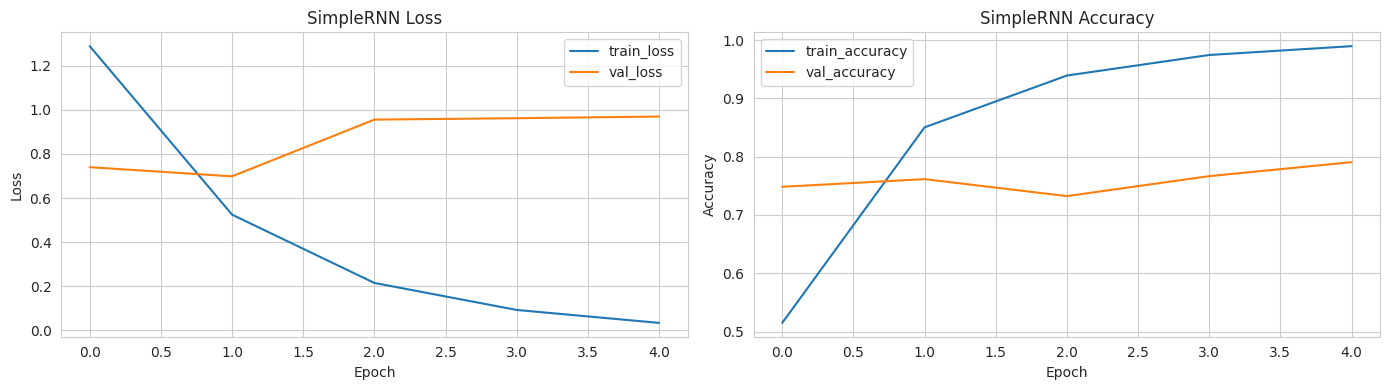

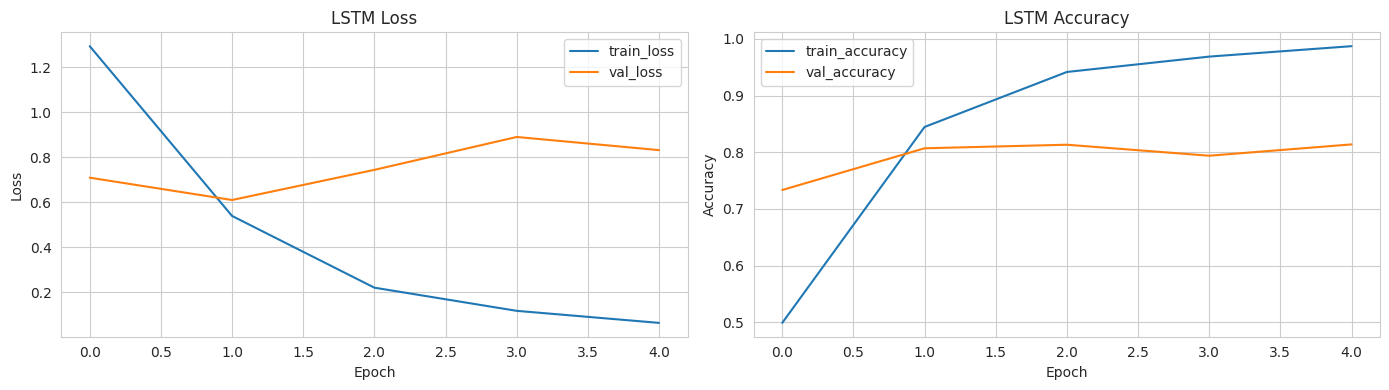

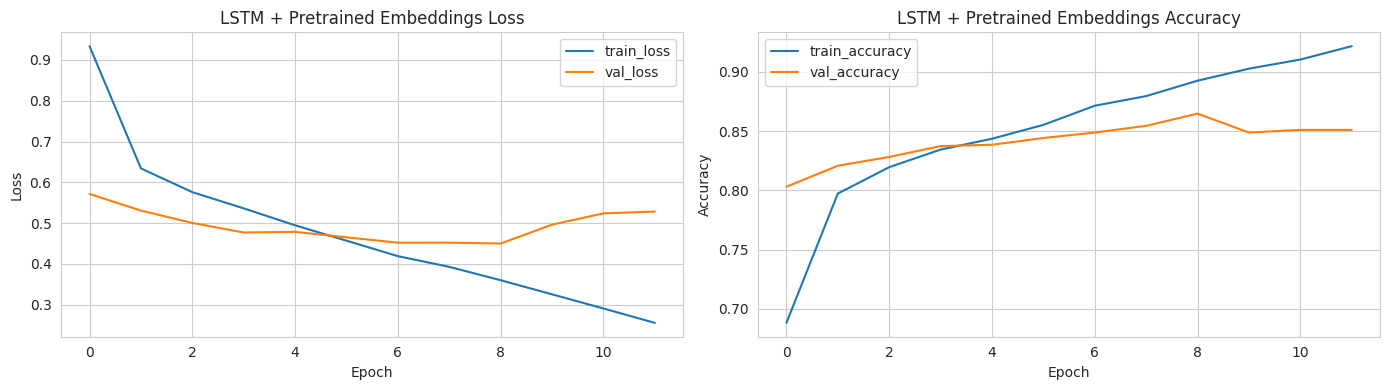

In [15]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(hist["loss"], label="train_loss")
    axes[0].plot(hist["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train_accuracy")
    axes[1].plot(hist["val_accuracy"], label="val_accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history_rnn, "SimpleRNN")
plot_history(history_lstm, "LSTM")
plot_history(history_pretrained, "LSTM + Pretrained Embeddings")

## Model Evaluation

Each model is evaluated using accuracy, macro/weighted F1-score, a classification report, and a confusion matrix. Macro F1 is useful here because the classes are imbalanced.


SimpleRNN
Accuracy: 0.7626
                precision    recall  f1-score   support

CULTURE & ARTS       0.55      0.69      0.61       211
     EDUCATION       0.59      0.68      0.63       203
         MONEY       0.63      0.82      0.71       351
        SPORTS       0.95      0.79      0.87      1015
          TECH       0.75      0.72      0.73       410

      accuracy                           0.76      2190
     macro avg       0.70      0.74      0.71      2190
  weighted avg       0.79      0.76      0.77      2190



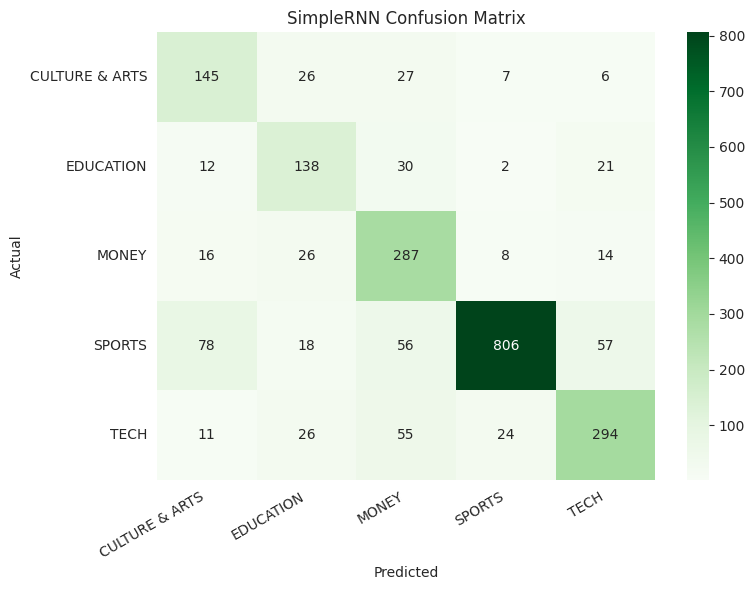


LSTM
Accuracy: 0.8055
                precision    recall  f1-score   support

CULTURE & ARTS       0.52      0.85      0.65       211
     EDUCATION       0.84      0.66      0.74       203
         MONEY       0.78      0.70      0.74       351
        SPORTS       0.96      0.87      0.91      1015
          TECH       0.72      0.80      0.76       410

      accuracy                           0.81      2190
     macro avg       0.76      0.77      0.76      2190
  weighted avg       0.83      0.81      0.81      2190



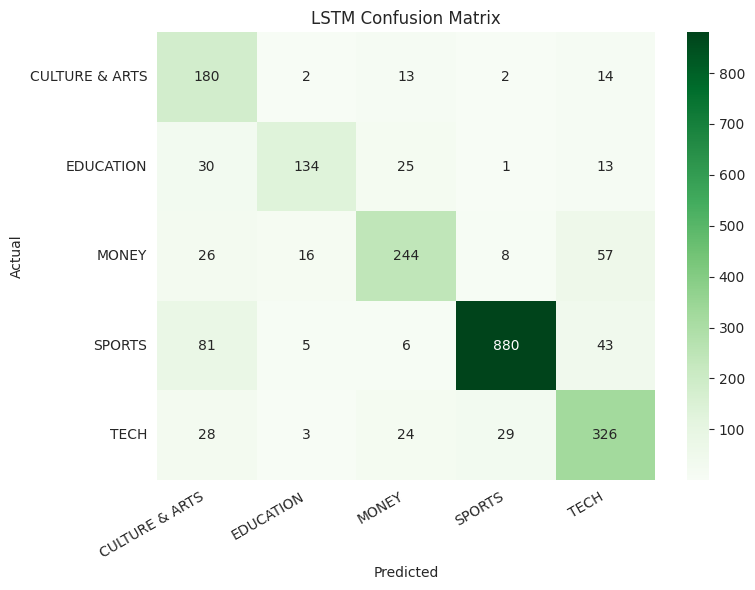


LSTM + Pretrained Embeddings
Accuracy: 0.8534
                precision    recall  f1-score   support

CULTURE & ARTS       0.78      0.74      0.76       211
     EDUCATION       0.75      0.76      0.76       203
         MONEY       0.77      0.84      0.80       351
        SPORTS       0.93      0.91      0.92      1015
          TECH       0.83      0.82      0.83       410

      accuracy                           0.85      2190
     macro avg       0.81      0.82      0.81      2190
  weighted avg       0.86      0.85      0.85      2190



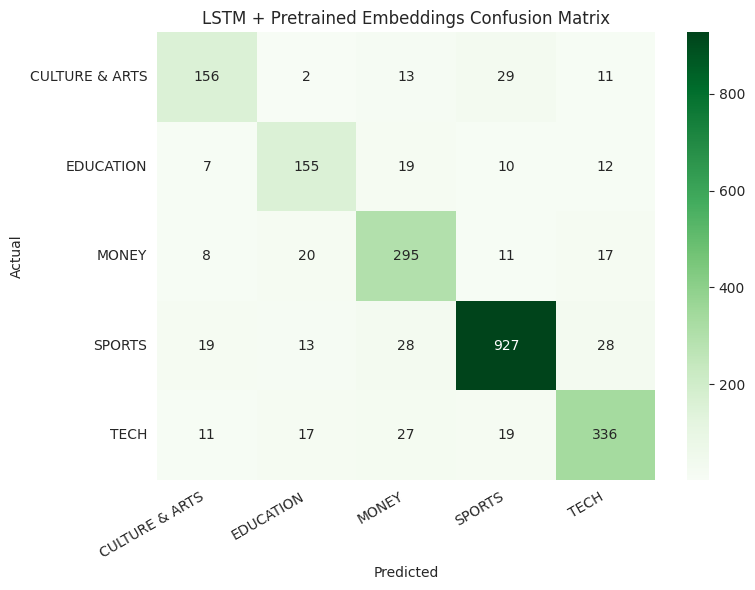

In [16]:
def evaluate_text_model(model, x_test, y_test_encoded, model_name):
    probabilities = model.predict(x_test, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    accuracy = accuracy_score(y_test_encoded, predictions)
    report = classification_report(
        y_test_encoded,
        predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )

    print(f"\n{model_name}")
    print("Accuracy:", round(accuracy, 4))
    print(classification_report(
        y_test_encoded,
        predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test_encoded, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": float(accuracy),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
    }, predictions, probabilities


rnn_metrics, rnn_preds, rnn_probs = evaluate_text_model(rnn_model, X_test_pad, y_test_encoded, "SimpleRNN")
lstm_metrics, lstm_preds, lstm_probs = evaluate_text_model(lstm_model, X_test_pad, y_test_encoded, "LSTM")
pretrained_metrics, pretrained_preds, pretrained_probs = evaluate_text_model(
    pretrained_lstm_model,
    X_test_pad,
    y_test_encoded,
    "LSTM + Pretrained Embeddings",
)

,model,accuracy,macro_f1,weighted_f1,training_time_seconds
2,LSTM + Pretrained Embeddings,0.853425,0.813155,0.853896,28.54
1,LSTM,0.805479,0.757377,0.811783,20.19
0,SimpleRNN,0.762557,0.711150,0.770258,18.06


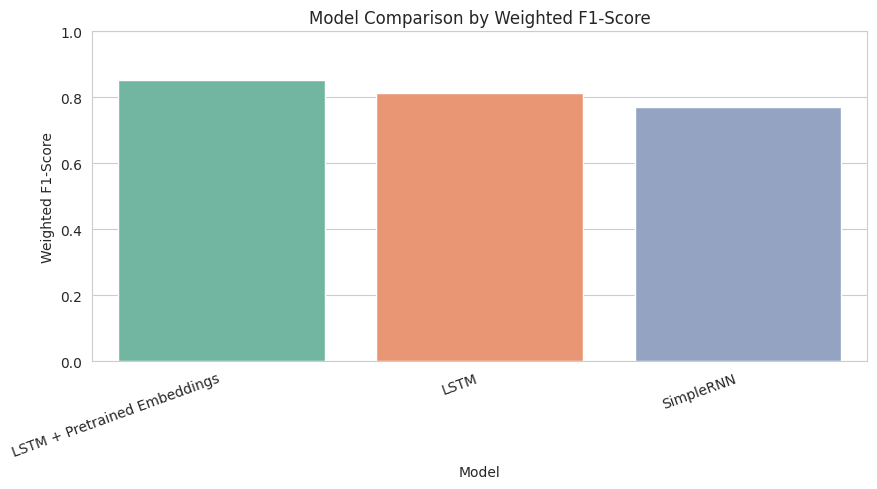

In [17]:
comparison_df = pd.DataFrame([
    {**rnn_metrics, "training_time_seconds": rnn_time},
    {**lstm_metrics, "training_time_seconds": lstm_time},
    {**pretrained_metrics, "training_time_seconds": pretrained_time},
]).sort_values(by="weighted_f1", ascending=False)

comparison_df["training_time_seconds"] = comparison_df["training_time_seconds"].round(2)
display(comparison_df)
comparison_df.to_csv("nlp_model_comparison.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x="model", y="weighted_f1", hue="model", palette="Set2", legend=False)
plt.title("Model Comparison by Weighted F1-Score")
plt.xlabel("Model")
plt.ylabel("Weighted F1-Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Error Analysis

The examples below use the best model by weighted F1-score. Review these rows in the report and explain likely causes such as short headlines, overlapping business/technology terms, category ambiguity, or class imbalance.

In [18]:
best_model_name = comparison_df.iloc[0]["model"]
best_predictions = {
    "SimpleRNN": rnn_preds,
    "LSTM": lstm_preds,
    "LSTM + Pretrained Embeddings": pretrained_preds,
}[best_model_name]
best_probabilities = {
    "SimpleRNN": rnn_probs,
    "LSTM": lstm_probs,
    "LSTM + Pretrained Embeddings": pretrained_probs,
}[best_model_name]

results_df = pd.DataFrame({
    "clean_text": X_test.reset_index(drop=True),
    "true_label": label_encoder.inverse_transform(y_test_encoded),
    "predicted_label": label_encoder.inverse_transform(best_predictions),
    "confidence": best_probabilities.max(axis=1),
})
results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

print("Best model for error analysis:", best_model_name)
misclassified = results_df[~results_df["correct"]].sort_values("confidence", ascending=False).head(3)
display(misclassified)

print("Suggested report note: explain whether these errors come from ambiguous wording, limited context in headlines, overlapping category vocabulary, or class imbalance.")

Best model for error analysis: LSTM + Pretrained Embeddings


,clean_text,true_label,predicted_label,confidence,correct
1423,tim berners lee honored london olympics openin...,TECH,SPORTS,0.997532,False
87,american think watching olympic opening ceremo...,TECH,SPORTS,0.996632,False
1101,ipad data fee soar due video streaming,MONEY,TECH,0.993644,False


Suggested report note: explain whether these errors come from ambiguous wording, limited context in headlines, overlapping category vocabulary, or class imbalance.


## Optional GUI for Real-Time Prediction

The assessment lists a GUI as an extra challenge. Run the following cell only after the models have trained. It uses the best-performing model from the comparison table.

In [21]:
# Optional extra challenge: Gradio app for real-time prediction in Colab.
# Uncomment and run this cell after training if you want the GUI output.

!pip install -q gradio
import gradio as gr

best_model_object = {
    "SimpleRNN": rnn_model,
    "LSTM": lstm_model,
    "LSTM + Pretrained Embeddings": pretrained_lstm_model,
}[best_model_name]

def predict_category(text):
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_length, padding="post", truncating="post")
    probabilities = best_model_object.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    return {
        "predicted_category": label_encoder.inverse_transform([predicted_index])[0],
        "confidence": float(probabilities[predicted_index]),
    }

demo = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=3, label="News headline"),
    outputs=gr.JSON(label="Prediction"),
    title="News Category Predictor",
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66f48e1e818db38bc2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
